<a href="https://www.kaggle.com/code/siryorch/ups-writing-skills-jcueva-kyansaguano?scriptVersionId=292250933" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os


In [2]:
import cv2

def noise_gauss(image, nivel=2):
    if nivel == 1:
        mean, sigma = 0, 10
    elif nivel == 2:
        mean, sigma = 0, 25
    elif nivel == 3:
        mean, sigma = 0, 50

    image_float = image.astype(np.float32)

    gaussian_noise = np.random.normal(mean, sigma, image.shape)
    noisy_image = image_float + gaussian_noise

    noisy_image = np.clip(noisy_image, 0, 255)
    return noisy_image.astype(np.uint8)


def noise_sp(image , nivel=2):
    if nivel == 1:
        salt = 0.01
        pepper = 0.01
    elif nivel == 2:
        salt = 0.02
        pepper = 0.02
    elif nivel == 3:
        salt = 0.04
        pepper = 0.04
    else:
        raise ValueError("nivel debe ser 1, 2 o 3")
    
    noisy_image = image.copy()
    h, w = image.shape[:2]

    total_pixels = h * w

    num_salt = int(total_pixels * salt)
    num_pepper = int(total_pixels * pepper)

    # Sal (blanco)
    coords = (
        np.random.randint(0, h, num_salt),
        np.random.randint(0, w, num_salt)
    )
    noisy_image[coords] = 255

    # Pimienta (negro)
    coords = (
        np.random.randint(0, h, num_pepper),
        np.random.randint(0, w, num_pepper)
    )
    noisy_image[coords] = 0

    return noisy_image

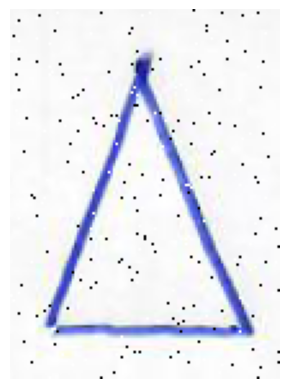

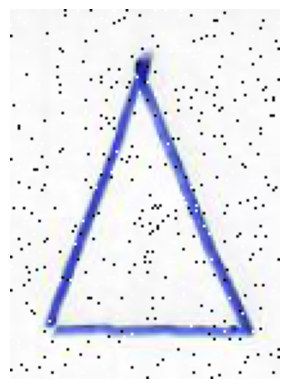

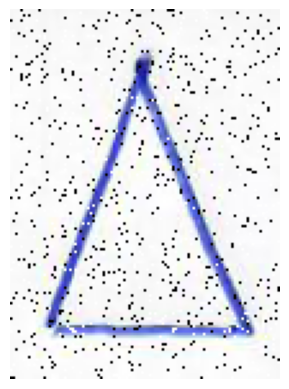

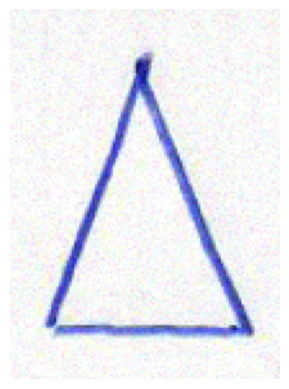

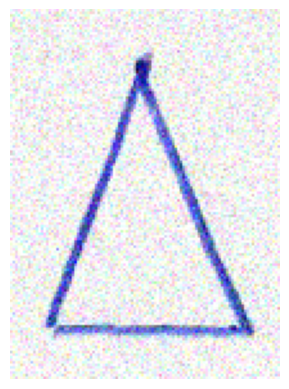

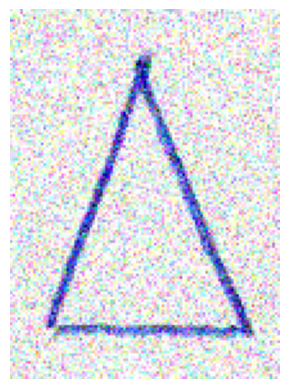

In [3]:
import matplotlib.pyplot as plt
import cv2

def show_image(img):
    if len(img.shape) == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.imshow(img)
    plt.axis("off")
    plt.show()

img = cv2.imread("/kaggle/input/ups-writing-skills/all-images/triangle/t10c-2.PNG")

# pruebas de ruido


img_3 = noise_sp(img,1)
img_1 = noise_sp(img,2)
img_2 = noise_sp(img,3)
show_image(img_3)
show_image(img_1)
show_image(img_2)

img = noise_gauss(img,1)
img_1 = noise_gauss(img,2)
img_2 = noise_gauss(img,3)
show_image(img)
show_image(img_1)
show_image(img_2)


In [4]:
import random

def augment_images_with_rotations(
    input_dir,
    output_dir,
    clones = 2
):

    os.makedirs(output_dir, exist_ok=True)

    for filename in os.listdir(input_dir):
        if not filename.lower().endswith((".png")):
            continue

        img_path = os.path.join(input_dir, filename)
        image = cv2.imread(img_path)

        if image is None:
            continue

        h, w = image.shape[:2]
        center = (w // 2, h // 2)

        name, ext = os.path.splitext(filename)

        for i in range (clones):
            # Matriz de rotación
            rot = random.randint(1, 359)
            M = cv2.getRotationMatrix2D(center, rot, 1.0)

            # Rotar imagen
            rotated = cv2.warpAffine(
                image,
                M,
                (w, h),
                flags=cv2.INTER_LINEAR,
                borderMode=cv2.BORDER_REFLECT
            )

            # Nombre de salida
            out_name = f"{name}_rot{rot}{ext}"
            out_path = os.path.join(output_dir, out_name)

            cv2.imwrite(out_path, rotated)


In [5]:
input_dir = "/kaggle/input/ups-writing-skills/all-images/"
output_dir = "/kaggle/working"
augment_images_with_rotations(input_dir+"circle",output_dir+"circle")
augment_images_with_rotations(input_dir+"square",output_dir+"square")
augment_images_with_rotations(input_dir+"triangle",output_dir+"triangle")